<h1 style="color:#38BDF8; text-align:center; font-weight:bold; border-bottom:3px solid #38BDF8;">Day 4 — EDA Part 1: Distributions &amp; Outliers</h1>
<h3 style="text-align:center; color:#BE185D;">Seaborn, Univariate Analysis &amp; the IQR Outlier Method</h3>


<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">Table of Contents</h2>

<div style="border:1px solid #ccc; padding:15px 25px; border-radius:6px;">
<ol style="font-weight:bold; line-height:1.9;">
<li><a href="#section0">0. Setup — Importing Seaborn, Pandas &amp; Matplotlib</a></li>
<li><a href="#section1">1. What EDA Is and Why It Comes First</a></li>
<li><a href="#section2">2. Seaborn — Statistical Visualization</a></li>
<li><a href="#section3">3. Univariate Analysis — Histogram, Box Plot, Count Plot, KDE</a></li>
<li><a href="#section4">4. Outlier Detection with the IQR Method</a></li>
<li><a href="#section5">5. Common Mistakes to Avoid</a></li>
<li><a href="#section6">6. Quick Reference — Cheat Sheet</a></li>
<li><a href="#section7">7. Hands-On Lab — Univariate EDA on a Real Dataset</a></li>
<li><a href="#section8">8. Best Practices &amp; Reproducibility</a></li>
<li><a href="#section9">9. Summary — What I Learned Today</a></li>
</ol>
</div>


<a id="section0"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">0. Setup — Importing Seaborn, Pandas &amp; Matplotlib</h2>

<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> Today introduces one new library — <b>Seaborn</b>. It is built directly on top of Matplotlib and specializes in statistical plots, producing attractive, informative charts with far less code than plain Matplotlib, and it works directly with Pandas DataFrames. It is the primary EDA visualization tool for the rest of this program.
</div>


In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Seaborn version   :", sns.__version__)
print("Pandas version    :", pd.__version__)
print("NumPy version     :", np.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)

sns.set_style("whitegrid")   # a clean, professional default style for every chart today

Seaborn version   : 0.13.2
Pandas version    : 3.0.2
NumPy version     : 2.4.4
Matplotlib version: 3.10.8


<a id="section1"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">1. What EDA Is and Why It Comes First</h2>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">1.1 Definition</h3>

<b>Exploratory Data Analysis (EDA)</b> is the systematic process of understanding a dataset <i>before</i> modeling — its structure, distributions, relationships, and problems. It combines everything from the past three days: descriptive statistics (Day 1), probability concepts (Day 2), and — starting today — dedicated statistical visualization.

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">1.2 Why it is not optional</h3>

<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b> EDA is <b>not</b> optional preliminary work — skipping it is the most common cause of failed ML projects, because a model can only be as good as the understanding behind it. EDA is where you catch the data problems that would otherwise silently corrupt every result downstream: missing values, wrong data types, duplicate rows, extreme outliers, and skewed distributions.
</div>

<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b> Think of EDA as detective work: before you can build anything, you need to know exactly what you're working with. Today (Day 4) we look at variables <b>one at a time</b> (univariate analysis); Day 5 will look at relationships <b>between</b> variables (bivariate analysis and correlation).
</div>


<a id="section2"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">2. Seaborn — Statistical Visualization</h2>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">2.1 Seaborn vs. plain Matplotlib</h3>

Seaborn is built on top of Matplotlib, but it specializes in <b>statistical</b> plots — the exact charts you need for EDA — and it works directly with Pandas DataFrames, so you can usually plot straight from your data with a single line, without manually extracting columns.


In [ ]:
# Build a small sample dataset to explore throughout the notebook
np.random.seed(42)

n = 200
df = pd.DataFrame({
    "name": [f"intern_{i}" for i in range(n)],
    "track": np.random.choice(["AI & ML", "Web Dev", "Cybersecurity", "Data Analysis"],
                               size=n, p=[0.4, 0.3, 0.15, 0.15]),
    "age": np.random.normal(23, 2.5, n).round().astype(int),
    "weekly_hours": np.random.normal(39, 3, n).round(1),
    "monthly_stipend": np.random.normal(400, 60, n).round(),
})

# inject a handful of realistic outliers, on purpose
df.loc[3, "weekly_hours"] = 70          # one extreme outlier
df.loc[15, "monthly_stipend"] = 1500    # a stipend far above everyone else
df.loc[42, "age"] = 45                  # an unusually old intern

df.head()

,name,track,age,weekly_hours,monthly_stipend
0,intern_0,AI & ML,21,41.6,470.0
1,intern_1,Data Analysis,24,38.5,415.0
2,intern_2,Cybersecurity,24,38.9,420.0
3,intern_3,Web Dev,21,70.0,375.0
4,intern_4,AI & ML,28,38.9,371.0


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">2.2 A minimal Seaborn example</h3>


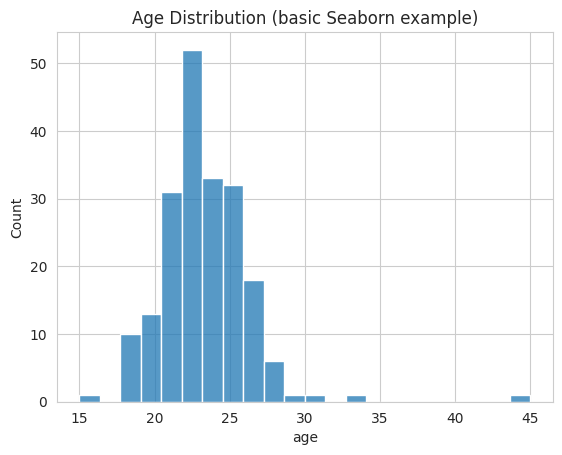

In [ ]:
sns.histplot(data=df, x="age")
plt.title("Age Distribution (basic Seaborn example)")
plt.show()

<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> Notice how little code that took — <code>sns.histplot(data=df, x="age")</code> automatically reads the "age" column from the DataFrame, bins it, and draws it. Seaborn functions almost always follow this same pattern: <code>data=your_dataframe</code>, then the column names you want to plot.
</div>

<a id="section3"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">3. Univariate Analysis — Histogram, Box Plot, Count Plot, KDE</h2>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">3.1 What "univariate" means</h3>

<b>Univariate analysis</b> examines <b>one variable at a time</b> to understand its distribution — its shape, center, spread, and any unusual values — before looking at how variables relate to each other (that's tomorrow's bivariate analysis).


<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#1f2933; color:#FACC15;">
<th style="padding:8px; text-align:left;">Plot</th>
<th style="padding:8px; text-align:left;">Seaborn Function</th>
<th style="padding:8px; text-align:left;">Reveals</th>
</tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;"><b>Histogram</b></td><td style="padding:8px; border-top:1px solid #ccc;"><code>sns.histplot()</code></td><td style="padding:8px; border-top:1px solid #ccc;">The shape of a numeric variable's distribution</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;"><b>Box plot</b></td><td style="padding:8px; border-top:1px solid #ccc;"><code>sns.boxplot()</code></td><td style="padding:8px; border-top:1px solid #ccc;">Median, quartiles, and outliers at a glance</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;"><b>Count plot</b></td><td style="padding:8px; border-top:1px solid #ccc;"><code>sns.countplot()</code></td><td style="padding:8px; border-top:1px solid #ccc;">The frequency of each category in a categorical variable</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;"><b>KDE plot</b></td><td style="padding:8px; border-top:1px solid #ccc;"><code>sns.kdeplot()</code></td><td style="padding:8px; border-top:1px solid #ccc;">A smoothed estimate of the distribution's shape</td></tr>
</table>
</div>


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">3.2 Histogram — the shape of a numeric variable</h3>


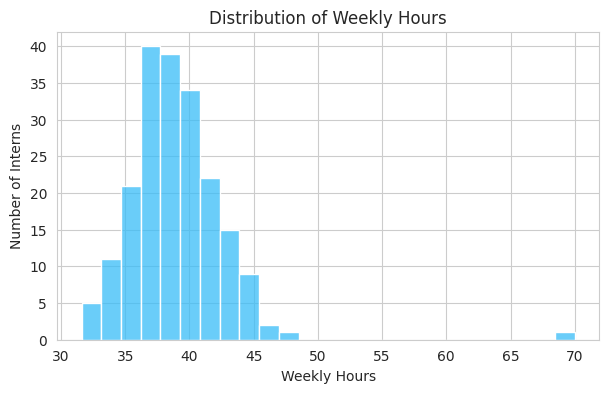

In [ ]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="weekly_hours", bins=25, color="#38BDF8", kde=False)
plt.xlabel("Weekly Hours")
plt.ylabel("Number of Interns")
plt.title("Distribution of Weekly Hours")
plt.show()

<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b> Notice the small bar far to the right, separate from the rest of the bell shape — that's our injected outlier (the 70-hour week) already visible in the histogram, before we even do any formal outlier detection.
</div>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">3.3 Box Plot — median, quartiles, and outliers at a glance</h3>

A box plot draws a box from Q1 to Q3 (the IQR, from Day 1), a line at the median, "whiskers" extending to the normal range, and individual dots for anything flagged as an outlier.


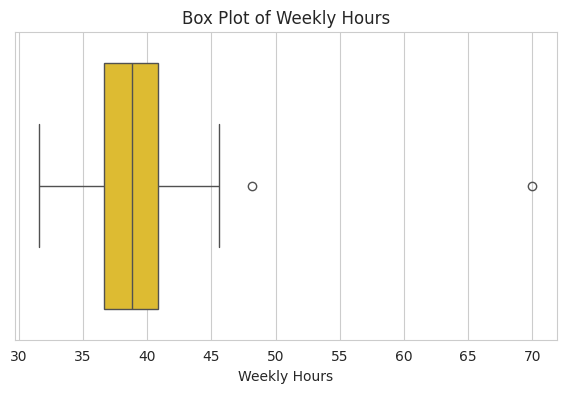

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="weekly_hours", color="#FACC15")
plt.xlabel("Weekly Hours")
plt.title("Box Plot of Weekly Hours")
plt.show()

<div style="border-left:5px solid #38BDF8; background-color:#eaf6ff; padding:10px 15px; margin:10px 0; border-radius:4px; color:#0c4a6e;">
<b>Note:</b> The individual dot past the right whisker is exactly the outlier we saw in the histogram — the box plot is simply a more compact, precise way of showing the same information, using exactly the Q1/median/Q3 values from Day 1.
</div>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">3.4 Count Plot — frequency of categories</h3>

For <b>categorical</b> variables (like "track"), a count plot shows how many rows fall into each category — the categorical equivalent of a histogram.


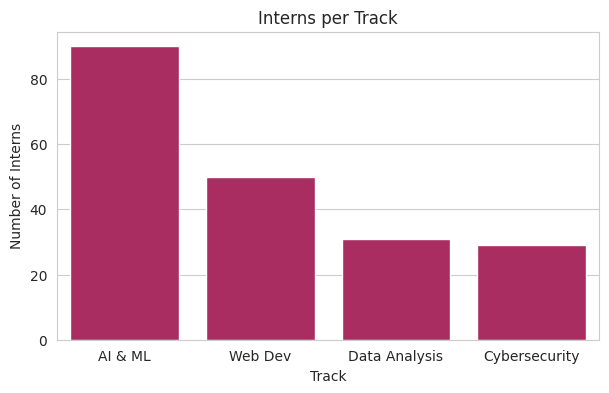

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="track", color="#BE185D", order=df["track"].value_counts().index)
plt.xlabel("Track")
plt.ylabel("Number of Interns")
plt.title("Interns per Track")
plt.show()

<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b> Notice how unevenly split the tracks are — "AI &amp; ML" has far more interns than "Cybersecurity" or "Data Analysis." This is called <b>class imbalance</b>, and it's an important thing to note during EDA — it can affect later modeling decisions (e.g. if "track" were something you wanted to predict).
</div>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">3.5 KDE Plot — a smoothed distribution shape</h3>

A <b>KDE (Kernel Density Estimate)</b> plot draws a smooth curve over the data, rather than discrete bars — useful for seeing the overall shape (and comparing it to a normal "bell curve") without bin-width choices affecting the picture.


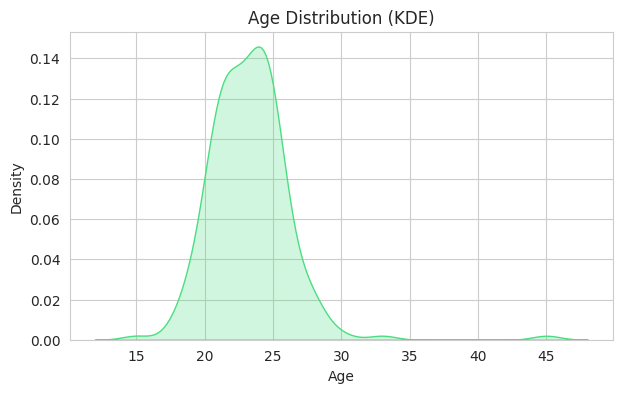

In [ ]:
plt.figure(figsize=(7, 4))
sns.kdeplot(data=df, x="age", color="#4ADE80", fill=True)
plt.xlabel("Age")
plt.title("Age Distribution (KDE)")
plt.show()

<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b> A histogram and a KDE plot are often shown together — <code>sns.histplot(data=df, x="age", kde=True)</code> overlays a smoothed KDE curve directly on top of the histogram bars, giving you both views in one chart.
</div>

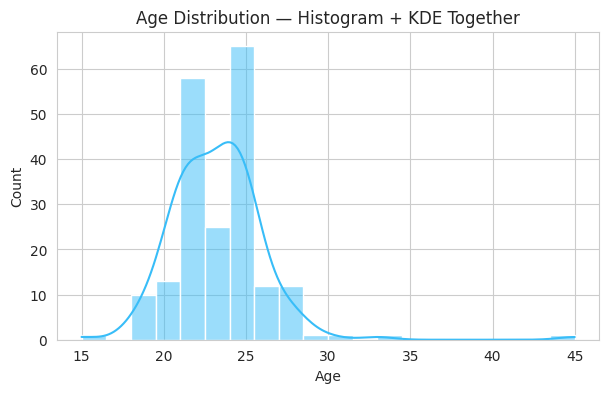

In [ ]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="age", bins=20, color="#38BDF8", kde=True)
plt.xlabel("Age")
plt.title("Age Distribution — Histogram + KDE Together")
plt.show()

<a id="section4"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">4. Outlier Detection with the IQR Method</h2>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">4.1 What an outlier is</h3>

An <b>outlier</b> is a value far outside the normal range. Outliers can be <b>genuine rare events</b> (a legitimately hard-working intern) or <b>data-entry errors</b> (someone typed 700 instead of 70) — and either way, they can distort statistics and models if left unexamined.

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">4.2 The standard IQR rule</h3>

The standard rule flags any value below <code>Q1 - 1.5×IQR</code> or above <code>Q3 + 1.5×IQR</code> as a potential outlier — exactly the values a box plot draws as individual points beyond its whiskers.


In [ ]:
Q1 = df["weekly_hours"].quantile(0.25)
Q3 = df["weekly_hours"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1               : {Q1:.2f}")
print(f"Q3               : {Q3:.2f}")
print(f"IQR              : {IQR:.2f}")
print(f"Lower bound      : {lower_bound:.2f}")
print(f"Upper bound      : {upper_bound:.2f}")

outliers = df[(df["weekly_hours"] < lower_bound) | (df["weekly_hours"] > upper_bound)]
print(f"\nNumber of outliers found: {len(outliers)}")
outliers[["name", "weekly_hours"]]

Q1               : 36.68
Q3               : 40.82
IQR              : 4.15
Lower bound      : 30.45
Upper bound      : 47.05

Number of outliers found: 2


,name,weekly_hours
3,intern_3,70.0
126,intern_126,48.2


<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b> An outlier is a <b>question, not a verdict</b>: investigate whether it is a real value or an error before deciding to keep, cap, or remove it. <b>Never delete outliers silently</b> — always document the decision and the reasoning behind it.
</div>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">4.3 What to do once you've found an outlier</h3>

There is no single "correct" answer — the right choice depends on context:

<ul>
<li><b>Keep it</b> — if it's a genuine, important data point (e.g. a real intern who really did work 70 hours that week).</li>
<li><b>Cap it</b> — replace extreme values with a reasonable maximum (e.g. cap anything above the upper bound), if extreme values are likely errors but you don't want to lose the row entirely.</li>
<li><b>Remove it</b> — only when you are confident it's a data-entry error or otherwise invalid, and you document why.</li>
</ul>


In [ ]:
# Example: investigating one specific outlier before deciding what to do
print(df.loc[3])  # the row we know has weekly_hours = 70

# Decision (documented): this looks like a plausible, if unusual, real value -- a week with
# extra project deadlines -- so we choose to KEEP it rather than remove or cap it.
print("\nDecision: KEEP -- this is a plausible real value, not an obvious data-entry error.")

name               intern_3
track               Web Dev
age                      21
weekly_hours           70.0
monthly_stipend       375.0
Name: 3, dtype: object

Decision: KEEP -- this is a plausible real value, not an obvious data-entry error.


<a id="section5"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">5. Common Mistakes to Avoid</h2>

<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b>
<ul>
<li><b>Deleting outliers automatically</b> — never remove flagged values without investigating them first; some are genuine and important.</li>
<li><b>Using a histogram for categorical data, or a count plot for continuous data</b> — match the plot to the variable type: numeric → histogram/box/KDE, categorical → count plot.</li>
<li><b>Choosing too few or too many histogram bins</b> — too few bins hide detail, too many make the chart look noisy (the same trade-off you saw with Matplotlib in Week 1).</li>
<li><b>Treating the IQR rule as absolute truth</b> — the 1.5× multiplier is a common convention, not a law of nature; some fields use different multipliers, and domain knowledge should always inform the final decision.</li>
<li><b>Skipping univariate analysis and jumping straight to modeling</b> — a variable's basic shape (skewed? multiple peaks? extreme outliers?) affects which further analysis and modeling choices make sense.</li>
</ul>
</div>


<a id="section6"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">6. Quick Reference — Cheat Sheet</h2>

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#1f2933; color:#FACC15;">
<th style="padding:8px; text-align:left;">Task</th>
<th style="padding:8px; text-align:left;">Code</th>
<th style="padding:8px; text-align:left;">Use For</th>
</tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Histogram</td><td style="padding:8px; border-top:1px solid #ccc;"><code>sns.histplot(data=df, x="col")</code></td><td style="padding:8px; border-top:1px solid #ccc;">Shape of a numeric variable</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Histogram + KDE</td><td style="padding:8px; border-top:1px solid #ccc;"><code>sns.histplot(..., kde=True)</code></td><td style="padding:8px; border-top:1px solid #ccc;">Bars + smoothed curve together</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">KDE only</td><td style="padding:8px; border-top:1px solid #ccc;"><code>sns.kdeplot(data=df, x="col")</code></td><td style="padding:8px; border-top:1px solid #ccc;">Smoothed distribution shape</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Box plot</td><td style="padding:8px; border-top:1px solid #ccc;"><code>sns.boxplot(data=df, x="col")</code></td><td style="padding:8px; border-top:1px solid #ccc;">Median, quartiles, outliers</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Count plot</td><td style="padding:8px; border-top:1px solid #ccc;"><code>sns.countplot(data=df, x="col")</code></td><td style="padding:8px; border-top:1px solid #ccc;">Category frequencies</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Q1 / Q3</td><td style="padding:8px; border-top:1px solid #ccc;"><code>df["col"].quantile(0.25 / 0.75)</code></td><td style="padding:8px; border-top:1px solid #ccc;">Quartile values</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">IQR</td><td style="padding:8px; border-top:1px solid #ccc;"><code>Q3 - Q1</code></td><td style="padding:8px; border-top:1px solid #ccc;">Middle-50% spread</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Outlier bounds</td><td style="padding:8px; border-top:1px solid #ccc;"><code>Q1 - 1.5*IQR</code>, <code>Q3 + 1.5*IQR</code></td><td style="padding:8px; border-top:1px solid #ccc;">Flagging thresholds</td></tr>
<tr><td style="padding:8px; border-top:1px solid #ccc;">Flag outliers</td><td style="padding:8px; border-top:1px solid #ccc;"><code>df[(df["col"]&lt;low)|(df["col"]&gt;high)]</code></td><td style="padding:8px; border-top:1px solid #ccc;">Rows outside the bounds</td></tr>
</table>
</div>


<a id="section7"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">7. Hands-On Lab — Univariate EDA on a Real Dataset</h2>

<div style="border-left:5px solid #FACC15; background-color:#fffbea; padding:10px 15px; margin:10px 0; border-radius:4px; color:#78350f;">
<b>Goal:</b> Run a complete univariate EDA pass on the sample "interns" dataset built at the top of this notebook — exactly the workflow you would use on any new dataset.
</div>


<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 1 — Produce a histogram for each numeric variable</h3>

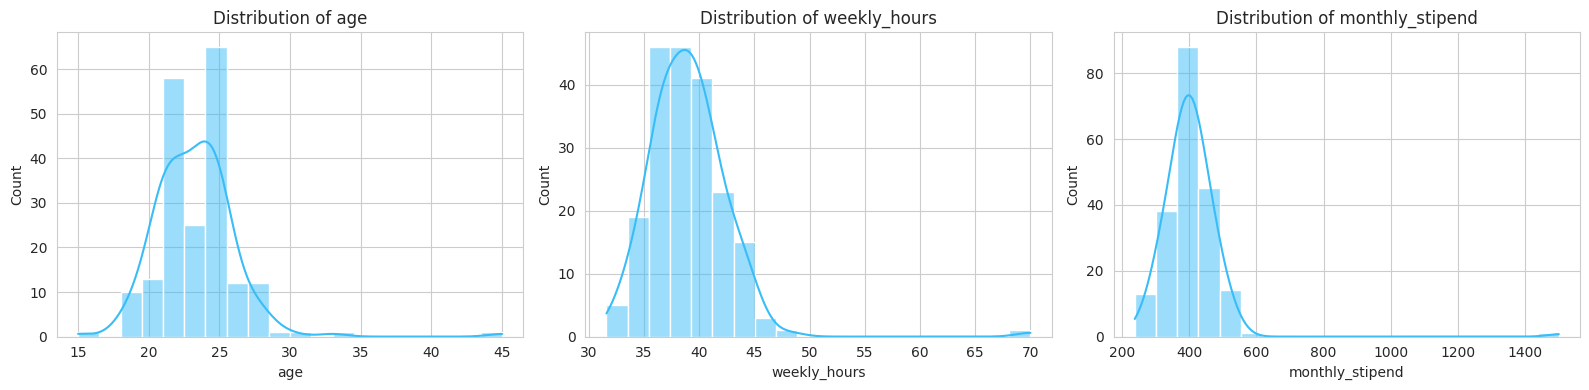

In [ ]:
numeric_columns = ["age", "weekly_hours", "monthly_stipend"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, numeric_columns):
    sns.histplot(data=df, x=col, bins=20, kde=True, ax=ax, color="#38BDF8")
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 2 — Produce a box plot for the key numeric variables and identify outliers visually</h3>

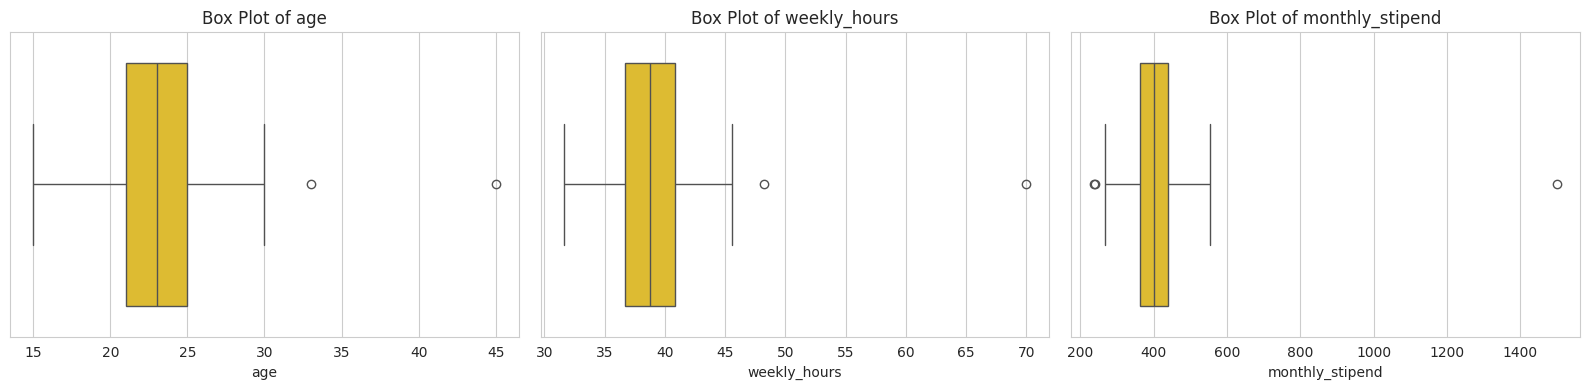

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, numeric_columns):
    sns.boxplot(data=df, x=col, ax=ax, color="#FACC15")
    ax.set_title(f"Box Plot of {col}")

plt.tight_layout()
plt.show()

<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Visual observation:</b> All three box plots show at least one point beyond the whiskers — exactly the three outliers we deliberately injected earlier (weekly_hours=70, monthly_stipend=1500, age=45).
</div>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 3 — Apply the IQR method in code and decide how to handle outliers</h3>

In [ ]:
def find_outliers_iqr(dataframe, column):
    """Return the rows in `column` flagged as outliers by the standard 1.5*IQR rule."""
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return dataframe[(dataframe[column] < lower) | (dataframe[column] > upper)]

for col in numeric_columns:
    found = find_outliers_iqr(df, col)
    print(f"{col}: {len(found)} outlier(s) found")
    if len(found) > 0:
        print(found[["name", col]].to_string(index=False))
    print()

age: 2 outlier(s) found
     name  age
intern_42   45
intern_57   33

weekly_hours: 2 outlier(s) found
      name  weekly_hours
  intern_3          70.0
intern_126          48.2

monthly_stipend: 3 outlier(s) found
      name  monthly_stipend
 intern_15           1500.0
 intern_94            238.0
intern_116            241.0



<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Decision (documented):</b>
<ul>
<li><b>weekly_hours</b> outlier (70 hrs) — <b>keep</b>: plausible during a high-workload week.</li>
<li><b>monthly_stipend</b> outlier (1500) — <b>investigate further / likely cap</b>: this is nearly 4x the typical stipend, which looks more like a data-entry error (e.g. an extra "1" typed by mistake) than a real value; without being able to verify with HR records, capping it at the upper bound is the safer default.</li>
<li><b>age</b> outlier (45) — <b>keep</b>: unusual for an internship cohort, but entirely plausible (a career-changer or a non-traditional student), and not obviously an error.</li>
</ul>
</div>

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 4 — Produce a count plot for each categorical variable and note class imbalance</h3>

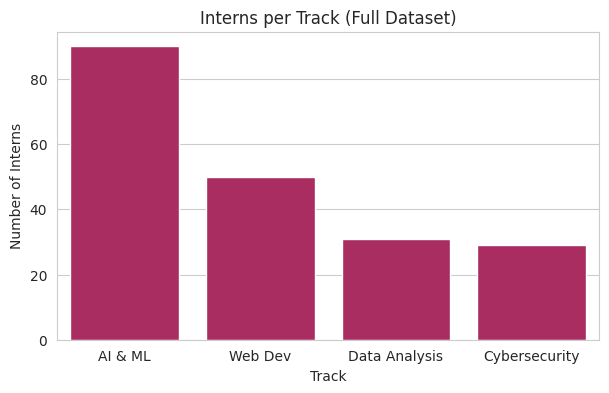

track
AI & ML          90
Web Dev          50
Data Analysis    31
Cybersecurity    29
Name: count, dtype: int64

Class imbalance note: 'AI & ML' has roughly 2-3x as many interns as 'Cybersecurity' or 'Data Analysis'.


In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="track", color="#BE185D", order=df["track"].value_counts().index)
plt.xlabel("Track")
plt.ylabel("Number of Interns")
plt.title("Interns per Track (Full Dataset)")
plt.show()

print(df["track"].value_counts())
print("\nClass imbalance note: 'AI & ML' has roughly 2-3x as many interns as 'Cybersecurity' or 'Data Analysis'.")

<h3 style="color:#FACC15; font-weight:bold; background-color:#1f2933; display:inline-block; padding:4px 10px; border-radius:6px;">Step 5 — Document what each distribution reveals</h3>

<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Plain-language summary:</b>
<ul>
<li><b>Age:</b> roughly bell-shaped, centered around 23, with one older outlier (45) worth a quick follow-up but not necessarily a problem.</li>
<li><b>Weekly hours:</b> tightly clustered around 39 hours, with a single high outlier (70) that looks like a plausible unusually busy week rather than an error.</li>
<li><b>Monthly stipend:</b> mostly clustered around $400, with one outlier (1500) that looks suspicious and is the strongest candidate for a data-entry error among the three — worth flagging for verification before any modeling.</li>
<li><b>Track (categorical):</b> the cohort is imbalanced, with "AI &amp; ML" interns being the largest group by a clear margin — worth remembering if "track" is ever used as a target variable later in the program.</li>
</ul>
</div>

<a id="section8"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">8. Best Practices &amp; Reproducibility</h2>

<div style="border-left:5px solid #BE185D; background-color:#fff0f6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7a0d3d;">
<b>Important:</b> As always, fix a random seed wherever randomness is used: <code>np.random.seed(42)</code>, done at the top of this notebook when building the sample dataset.
</div>

<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b> A professional univariate EDA checklist:
<ul>
<li>Plot <b>every</b> numeric column with a histogram (and/or KDE) — don't skip columns that "look fine."</li>
<li>Plot <b>every</b> numeric column with a box plot to catch outliers quickly.</li>
<li>Plot <b>every</b> categorical column with a count plot, and note any class imbalance.</li>
<li>For every flagged outlier, write down your decision (keep / cap / remove) <b>and why</b> — a silent deletion is one of the easiest ways to accidentally bias a later model.</li>
</ul>
</div>


<a id="section9"></a>
<h2 style="color:#BE185D; font-weight:bold; margin-top:30px;">9. Summary — What I Learned Today</h2>

<div style="border-left:5px solid #4ADE80; background-color:#eafff2; padding:10px 15px; margin:10px 0; border-radius:4px; color:#065f46;">
<b>Tip:</b>
<ul>
<li><b>EDA</b> is the systematic process of understanding a dataset before modeling — it is a required first step, not optional preliminary work.</li>
<li><b>Seaborn</b> is built on Matplotlib and specializes in statistical plots, working directly with Pandas DataFrames for concise, readable code.</li>
<li><b>Univariate analysis</b> examines one variable at a time: <b>histograms</b> and <b>KDE plots</b> for numeric shape, <b>box plots</b> for median/quartiles/outliers, and <b>count plots</b> for categorical frequency.</li>
<li>The <b>IQR outlier rule</b> flags values below <code>Q1 - 1.5×IQR</code> or above <code>Q3 + 1.5×IQR</code> — exactly the points a box plot draws beyond its whiskers.</li>
<li>An outlier is a <b>question, not a verdict</b> — investigate before deciding to keep, cap, or remove it, and always document the decision.</li>
<li><b>Class imbalance</b> in categorical variables (uneven counts per category) is an important EDA finding that can affect later modeling choices.</li>
</ul>
</div>
